In [1]:
import math
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from common import (
    apply_style,
    save_fig,
    PLOT_DPI,
    LABEL_FONTSIZE,
    TICK_FONTSIZE,
    TITLE_FONTSIZE,
    FONT_COLOR,
    TICK_FONTS_COLOR,
    BAR_TEXT_COLOR,
    BAR_LABEL_FONTSIZE,
)

# List of (label, csv_path) pairs — add more entries to plot additional bars.
inputs = [
    ("Regular: [0.1, 0.2, 0.3]", Path("benchmark_summaries/benchmark_summary_arxiv_PDXEARCH_20260320_131250.csv")),
    ("Blob: \"[0.1, 0.2, 0.3]\"", Path("benchmark_summaries/benchmark_summary_arxiv_PDXEARCH_20260320_131037.csv")),
    # ("Regular, Non-filtered", Path("benchmark_summaries/benchmark_summary_arxiv_PDXEARCH_20260320_125857.csv")),
    # ("Blob, Non-filtered", Path("benchmark_summaries/benchmark_summary_arxiv_PDXEARCH_20260320_130048.csv")),
    # ("Regular, Filtered", Path("benchmark_summaries/benchmark_summary_arxiv_PDXEARCH_20260320_124729.csv")),
    # ("Blob, Filtered", Path("benchmark_summaries/benchmark_summary_arxiv_PDXEARCH_20260320_123939.csv")),
]

# Stacking order: bottom-to-top matches DuckDB execution order.
components = [
    "avg_planner",
    "avg_all_optimizers",
    "avg_physical_planner",
    "avg_filtered_sequential_scan_duration",
    "avg_calc_index_scan_duration",
    "avg_other_operators_duration",
]

# Display names for legend/labels. Falls back to the raw column name if not listed.
component_labels = {
    "avg_other_operators_duration": "Other Operators",
    "avg_calc_index_scan_duration": "PDXearch Index Scan",
    "avg_filtered_sequential_scan_duration": "Filtered Seq. Scan",
    "avg_planner": "Planner",
    "avg_physical_planner": "Physical Planner",
    "avg_all_optimizers": "Optimizers",
}

title = "Benchmark Timing Breakdown"
subtitle = "ArxivForFanns (1.2M × 1024, Original; Recall@10: 80%)\nPDXearch Row Group (F32), 1 thread"
ylabel = "Milliseconds"
figsize = (5.5, 5)

output = Path("benchmark_summaries/stacked_compare_pdxearch_rowgroup_vs_global_sorted_notebook")

Saved plot to: benchmark_summaries/stacked_compare_pdxearch_rowgroup_vs_global_sorted_notebook


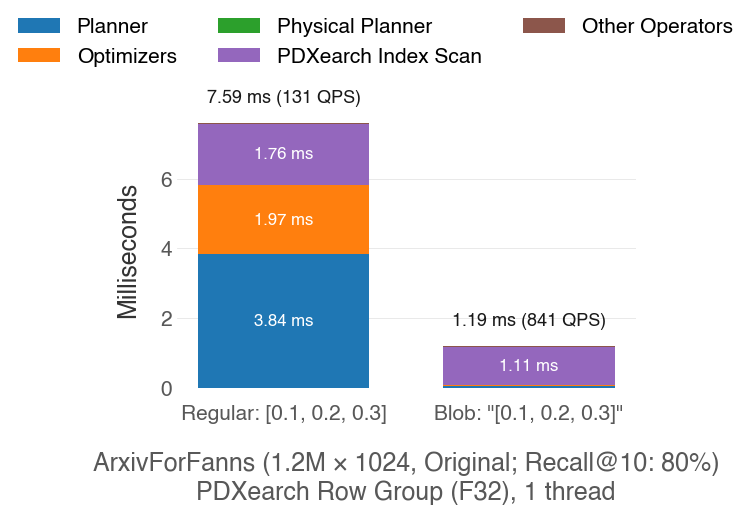

In [2]:
def load_summary(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")
    df = pd.read_csv(path)
    if df.empty:
        raise ValueError(f"CSV is empty: {path}")
    return df


def extract_component_means(df: pd.DataFrame, cols: list[str], path: Path) -> list[float]:
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"{path} is missing required columns: {', '.join(missing)}")
    return [float(pd.to_numeric(df[c], errors="coerce").mean()) for c in cols]


def extract_avg_qps_and_recall(df: pd.DataFrame, path: Path) -> tuple[float, float]:
    required = ["avg_latency", "avg_recall"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(
            f"{path} is missing required columns for QPS/recall labels: {', '.join(missing)}"
        )

    avg_latency = float(pd.to_numeric(df["avg_latency"], errors="coerce").mean())
    avg_recall = float(pd.to_numeric(df["avg_recall"], errors="coerce").mean())

    if avg_latency <= 0:
        raise ValueError(f"{path} has non-positive avg_latency={avg_latency}, cannot compute QPS")

    avg_qps = 1.0 / avg_latency
    return avg_qps, avg_recall


apply_style()

# Load data for each input
all_vals = []
all_qps = []
all_labels = []
for label, path in inputs:
    df = load_summary(path)
    vals = extract_component_means(df, components, path)
    qps, recall = extract_avg_qps_and_recall(df, path)
    # Convert seconds → milliseconds
    vals_ms = [v * 1000.0 for v in vals]
    all_vals.append(vals_ms)
    all_qps.append(qps)
    all_labels.append(f"{label}")
    # all_labels.append(f"{label}\nRecall: {recall * 100:.1f}%")

# Determine which components are all-zero across every bar and exclude them
active_comp_indices = [
    i for i in range(len(components))
    if any(all_vals[bar_idx][i] != 0.0 for bar_idx in range(len(inputs)))
]
active_components = [components[i] for i in active_comp_indices]
active_vals = [[vals[i] for i in active_comp_indices] for vals in all_vals]

n_bars = len(inputs)
x = list(range(n_bars))
width = 0.7

fig, ax = plt.subplots(figsize=figsize)
bottoms = [0.0] * n_bars

# Track bar segments for inside labels
bar_segments: list[list[tuple[float, float, int]]] = [[] for _ in range(n_bars)]

for comp_idx, component in enumerate(active_components):
    color = f"C{active_comp_indices[comp_idx] % 10}"
    display_name = component_labels.get(component, component)
    for bar_idx in range(n_bars):
        val = active_vals[bar_idx][comp_idx]
        ax.bar(x[bar_idx], val, width=width,
               bottom=bottoms[bar_idx], color=color,
               label=display_name if bar_idx == 0 else None)
        bar_segments[bar_idx].append((bottoms[bar_idx], val, comp_idx))
        bottoms[bar_idx] += val

# Determine the total height to decide a minimum fraction for labeling
max_total = max(sum(v) for v in active_vals)

for bar_idx in range(n_bars):
    for bottom, val, comp_idx in bar_segments[bar_idx]:
        # Only label segments that are at least 8% of the tallest bar
        if val / max_total >= 0.08:
            center_y = bottom + val / 2
            ax.text(x[bar_idx], center_y, f"{val:.2f} ms",
                    ha="center", va="center",
                    fontsize=BAR_LABEL_FONTSIZE - 1, color="white", fontweight="bold")

for i in range(n_bars):
    total = sum(active_vals[i])
    ax.annotate(f"{total:.2f} ms ({math.floor(all_qps[i]):.0f} QPS)", xy=(i, total), xytext=(0, 12),
                textcoords="offset points", ha="center", va="bottom",
                fontsize=BAR_LABEL_FONTSIZE, color=BAR_TEXT_COLOR)

ax.set_xticks(x, all_labels)
ax.set_ylabel(ylabel, fontsize=LABEL_FONTSIZE, color=FONT_COLOR, labelpad=15)
ax.set_xlabel(subtitle, fontsize=LABEL_FONTSIZE, color=TICK_FONTS_COLOR, labelpad=20)
# ax.set_title(title, fontsize=TITLE_FONTSIZE, color=FONT_COLOR, pad=30)

ax.grid(axis="y", linestyle='-', linewidth=0.6, color='gray', alpha=0.2)
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis='both', colors=TICK_FONTS_COLOR, length=0)
ax.tick_params(axis='x', labelsize=TICK_FONTSIZE, pad=12)
ax.tick_params(axis='y', labelsize=TICK_FONTSIZE)

fig.legend(loc="upper center", ncol=math.ceil(len(active_components) / 2),
           frameon=False, fontsize=TICK_FONTSIZE, bbox_to_anchor=(0.5, 1.04))

fig.tight_layout(rect=[0, 0, 1, 0.88])

output.parent.mkdir(parents=True, exist_ok=True)
save_fig(str(output))
print(f"Saved plot to: {output}")
plt.show()